# 10 · Fitting implicit models: how rough is this pipe?

**Problem.** Pressure drops were measured over 20 m of a 50 mm pipe at several flow rates. The
pipe's roughness $\varepsilon$ is unknown, and the flow meter may read a few percent low (unknown
factor $k$). The model is
$$\Delta P = f\,\frac{L}{D}\,\frac{\rho v^2}{2},\qquad v = \frac{4kQ}{\pi D^2},$$
where $f$ solves the **implicit** Colebrook equation. Each model prediction therefore requires a
root-finding problem (notebook 02) *inside* the least-squares problem - a common situation with
equilibrium, phase and flow models. The measurements are in `pipe_pressure_drop.csv` (synthetic data
with 2 % measurement error, generated with known "true" values so that the fit can be checked).

**What you will learn**

- fit a model that needs a root solve inside every evaluation
- minimise one parameter by golden-section search and several by Nelder-Mead
- choose relative or absolute residuals
- read an objective-function landscape to diagnose correlated parameters

**Before you start:** notebooks 02 (Colebrook equation) and 09  ·  **Time:** about 60 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import optimize, roots

In [2]:
rho, mu, L, D = 998.0, 1.0e-3, 20.0, 0.05

def friction(Re, eps):
    g = lambda f: 1/np.sqrt(f) + 2*np.log10(eps/D/3.7 + 2.51/(Re*np.sqrt(f)))
    return roots.brent(g, 1e-4, 0.2).root

def dp_model(Q, eps, k=1.0):
    v = 4*k*Q/(np.pi*D**2)
    Re = rho*v*D/mu
    return np.array([friction(Ri, eps) for Ri in np.atleast_1d(Re)]) * L/D * rho*v**2/2

from engmath import datasets
meas = np.loadtxt(datasets.path("pipe_pressure_drop.csv"), delimiter=",", skiprows=1)
Q, dp = meas[:, 0], meas[:, 1]                                # m3/s, Pa
eps_true, k_true = 0.15e-3, 1.03          # used to synthesise the file (unknown in a real test) - for checking only
for q, d in zip(Q, dp):
    print(f"Q = {q*1000:4.1f} L/s   ΔP = {d/1000:8.2f} kPa")

Q =  0.5 L/s   ΔP =     0.46 kPa
Q =  1.0 L/s   ΔP =     1.65 kPa
Q =  2.0 L/s   ΔP =     6.21 kPa
Q =  3.0 L/s   ΔP =    13.07 kPa
Q =  4.0 L/s   ΔP =    24.96 kPa
Q =  5.0 L/s   ΔP =    38.17 kPa
Q =  6.0 L/s   ΔP =    53.08 kPa
Q =  8.0 L/s   ΔP =    95.71 kPa


## One parameter: golden-section search
Assume the flow meter is right ($k$ = 1) and search for the roughness that minimises the sum of
squared **relative** residuals. The pressure drops span two orders of magnitude, so absolute residuals
would let the highest flow dominate completely (compare exercise 1).

In [3]:
def rss(log_eps, k=1.0):
    return np.sum(np.log(dp_model(Q, 10**log_eps, k) / dp)**2)

r1 = optimize.golden_section(rss, -6, -2.5)
print(f"roughness (k fixed at 1): {10**r1.x[0]*1000:.3f} mm   (true {eps_true*1000} mm)")

roughness (k fixed at 1): 0.193 mm   (true 0.15 mm)


## Inside the algorithm: golden-section search
Keep two interior points that divide the bracket in the golden ratio. Compare their function values and
discard the part of the bracket that cannot contain the minimum. One old point is always reused, so each
step costs only **one** new evaluation - important when every evaluation hides eight Colebrook solves:

In [4]:
def golden_by_hand(f, a, b, tol=1e-6):
    g = (np.sqrt(5) - 1) / 2                   # 0.618...
    c, d = b - g * (b - a), a + g * (b - a)
    fc, fd = f(c), f(d)
    evaluations = 2
    while b - a > tol:
        if fc < fd:                            # the minimum lies in [a, d]
            b, d, fd = d, c, fc
            c = b - g * (b - a)
            fc = f(c)
        else:                                  # the minimum lies in [c, b]
            a, c, fc = c, d, fd
            d = a + g * (b - a)
            fd = f(d)
        evaluations += 1
    return (a + b) / 2, evaluations

x_min, n_eval = golden_by_hand(rss, -6, -2.5)
print(f"roughness {10**x_min*1000:.3f} mm after {n_eval} evaluations (library: {10**r1.x[0]*1000:.3f} mm)")

roughness 0.193 mm after 34 evaluations (library: 0.193 mm)


Wrong! Forcing $k = 1$ makes the fit blame the low flow reading on the pipe. Both unknowns must be
estimated together.

## Two parameters: the Nelder-Mead simplex
With no derivatives available (each evaluation hides eight root solves), a derivative-free method
is natural. Optimising $\log_{10}\varepsilon$ rather than $\varepsilon$ keeps the parameters on similar
scales and keeps $\varepsilon$ positive.

In [5]:
r2 = optimize.nelder_mead(lambda p: rss(p[0], p[1]), [-4.0, 1.0], step=0.05, tol=1e-12)
eps_fit, k_fit = 10**r2.x[0], r2.x[1]
print(f"roughness {eps_fit*1000:.3f} mm (true {eps_true*1000}),  meter factor {k_fit:.4f} (true {k_true})")
print(f"{r2.iterations} simplex iterations, converged: {r2.converged}")
print(f"RSS at the fit {r2.fun:.5f}  vs  RSS at the TRUE parameters {rss(np.log10(eps_true), k_true):.5f}")

roughness 0.168 mm (true 0.15),  meter factor 1.0166 (true 1.03)
89 simplex iterations, converged: True
RSS at the fit 0.00459  vs  RSS at the TRUE parameters 0.00474


Much better than fixing $k = 1$, yet not equal to the truth - and the fit is **not** wrong: its RSS is
*lower* than at the true parameters. With 2 % noise these data genuinely cannot pin down both
parameters more precisely. Why?

## Looking at the objective function explains a lot

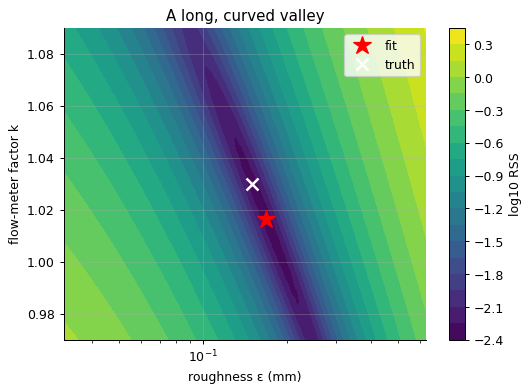

In [6]:
le = np.linspace(-4.5, -3.2, 60); kk = np.linspace(0.97, 1.09, 60)
Z = np.array([[rss(a, b) for a in le] for b in kk])
fig, ax = plt.subplots(figsize=(6.5, 4.5))
cs = ax.contourf(10**le*1000, kk, np.log10(Z), levels=25, cmap="viridis")
fig.colorbar(cs, label="log10 RSS")
ax.plot(eps_fit*1000, k_fit, "r*", ms=15, label="fit"); ax.plot(eps_true*1000, k_true, "wx", ms=10, mew=2, label="truth")
ax.set(xscale="log", xlabel="roughness ε (mm)", ylabel="flow-meter factor k", title="A long, curved valley")
ax.legend(); plt.show()

The valley is long and narrow: roughness and meter factor partly compensate each other, so they are
correlated. Better-designed experiments (e.g. adding laminar-flow points, where $f = 64/Re$ does not
depend on $\varepsilon$ at all) would pin $k$ down independently - **experimental design and
numerical methods go together.**

## Exercises
1. Repeat the two-parameter fit with absolute residuals $\sum(\Delta P_{model} - \Delta P)^2$. How much
   do the estimates change, and why?
2. Add three laminar points ($Re$ < 2000, use $f = 64/Re$) to the data and refit. How does the shape
   of the valley change?
3. Replace Colebrook with the explicit Haaland approximation inside the model. How large is the
   resulting bias in $\varepsilon$, and is it smaller than the statistical uncertainty?
4. **Implement it yourself:** a grid search over $\log_{10}\varepsilon \in [-6, -2.5]$ that reaches the same final precision needs how many evaluations? Implement it and compare with golden-section search.